In [1]:
pip install scikit_posthocs

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from scipy.stats import poisson, chi2

In [24]:
df_treatment = pd.read_csv("data_csvs/Data_TreatmentTimes.csv")
df_treatment.info()
df_treatment.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18565 entries, 0 to 18564
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     18565 non-null  int64  
 1   Treatment Time (Days)  18565 non-null  float64
 2   Specialty              18565 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 435.2+ KB


,ID,Treatment Time (Days),Specialty
0,0,4.640229,Ortho
1,1,0.770322,Renal
2,2,1.911212,Card
3,3,4.199311,Respi
4,4,2.527663,Gastro_Endo


In [25]:
df_treatment.columns.tolist()


['ID', 'Treatment Time (Days)', 'Specialty']

In [28]:
#reindex the dataframe
df_treatment = df_treatment.rename(columns={"Treatment Time (Days)": "TreatmentTime"})
# bro why is this not working
#df_treatment = df_treatment.set_index('ID')
df_treatment

,TreatmentTime,Specialty
ID,,
0,4.640229,Ortho
1,0.770322,Renal
2,1.911212,Card
3,4.199311,Respi
4,2.527663,Gastro_Endo
...,...,...
18560,3.715383,Respi
18561,2.305584,Respi
18562,7.595695,Gastro_Endo


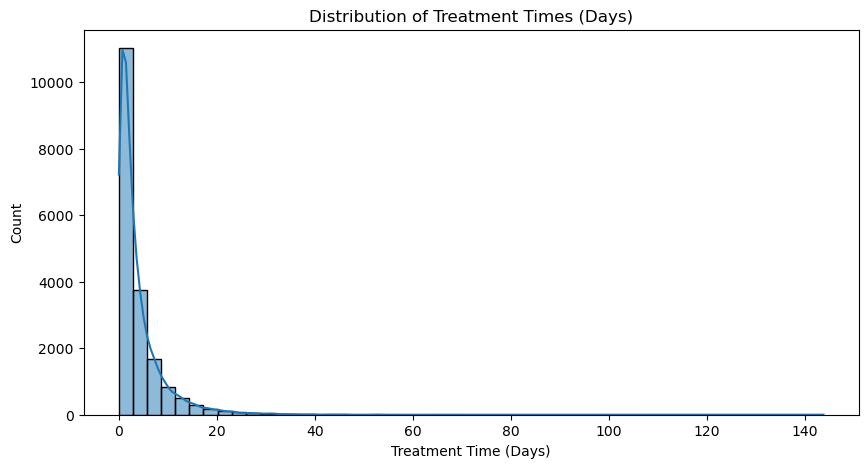

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df_treatment["TreatmentTime"], kde=True, bins=50)
plt.title("Distribution of Treatment Times (Days)")
plt.xlabel("Treatment Time (Days)")
plt.ylabel("Count")
plt.show()


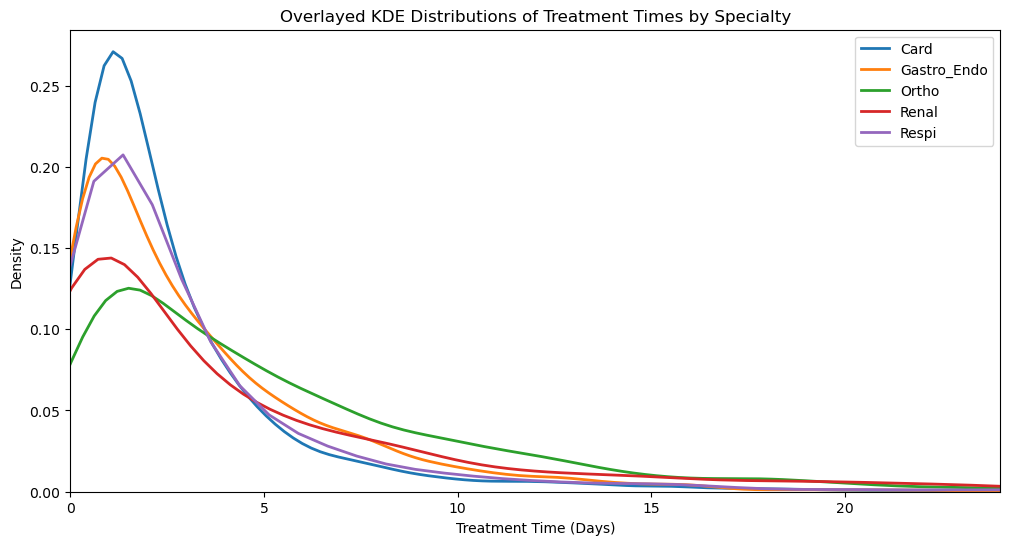

In [35]:
plt.figure(figsize=(12,6))

for spec, df in df_treatment.groupby("Specialty"):
    sns.kdeplot(df["TreatmentTime"], label=spec, linewidth=2)

plt.title("Overlayed KDE Distributions of Treatment Times by Specialty")
plt.xlabel("Treatment Time (Days)")
plt.ylabel("Density")
plt.legend()
plt.xlim(0, df_treatment["TreatmentTime"].quantile(0.99))  # cut extreme outliers
plt.show()

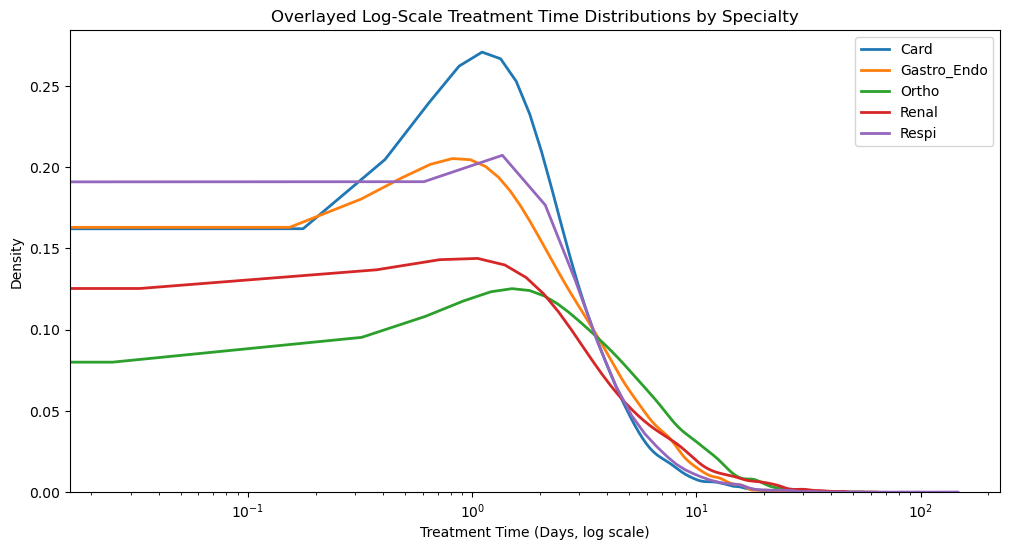

In [34]:
plt.figure(figsize=(12,6))

for spec, df in df_treatment.groupby("Specialty"):
    sns.kdeplot(df["TreatmentTime"], label=spec, linewidth=2)

plt.xscale("log")
plt.title("Overlayed Log-Scale Treatment Time Distributions by Specialty")
plt.xlabel("Treatment Time (Days, log scale)")
plt.ylabel("Density")
plt.legend()
plt.show()



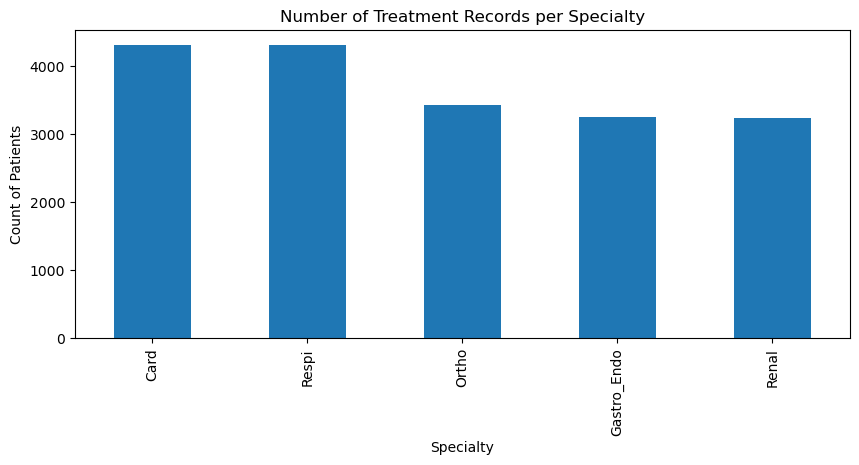

In [31]:
plt.figure(figsize=(10,4))
df_treatment["Specialty"].value_counts().plot(kind="bar")
plt.ylabel("Count of Patients")
plt.title("Number of Treatment Records per Specialty")
plt.show()
